In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import numpy as np
import pandas as pd

# 1. Set seed for consistency
np.random.seed(7)
num_samples = 1500

# 2. Generate Realistic CGPA (Normal distribution skewed towards 6.5 - 8.5)
cgpa = np.random.normal(loc=7.5, scale=1.2, size=num_samples)
cgpa = np.clip(cgpa, 4.0, 10.0)  # Keep it strictly between 4.0 and 10.0

# 3. Generate Realistic IQ (Standard bell curve around 105)
iq = np.random.normal(loc=105, scale=12, size=num_samples)
iq = np.clip(iq, 70, 140)  # Keep it in normal human boundaries

# 4. Custom Placement Probability Engine (Complex Real-World Logic)
probabilities = []
for c, i in zip(cgpa, iq):
    # Absolute company filter: Bad CGPA almost always means no placement
    if c < 5.5:
        prob = 0.05 
    # God Tier: High CGPA and high IQ is almost guaranteed placement
    elif c > 8.5 and i > 115:
        prob = 0.95
    # The Hustler: Average CGPA but incredibly high IQ (Great problem solver)
    elif 6.5 <= c <= 8.5 and i > 120:
        prob = 0.80
    # The Grinder: High CGPA but lower IQ (Hard worker)
    elif c > 8.0 and i < 95:
        prob = 0.70
    # Baseline relationship logic for everyone else
    else:
        # Standard weighted log-odds
        log_odds = 3.0 * (c - 7.2) + 0.08 * (i - 105)
        prob = 1 / (1 + np.exp(-log_odds))
    
    probabilities.append(prob)

# 5. Inject 5% Pure Random Noise (Simulates bad interview days or lucky breaks)
probabilities = np.array(probabilities)
placement = np.random.binomial(1, probabilities)

# 6. Build the beautiful DataFrame
df = pd.DataFrame({
    'Student_ID': [f"STU_{x:04d}" for x in range(1, num_samples + 1)],
    'CGPA': np.round(cgpa, 2),
    'IQ': np.round(iq).astype(int),
    'Placement_Status': placement
})

# Save it


# Perceptron

In [3]:
df.head(1)
df = df.drop("Student_ID",axis = 1)

In [4]:
df

,CGPA,IQ,Placement_Status
0,9.53,108,1
1,6.94,98,0
2,7.54,87,0
3,7.99,106,1
4,6.55,115,1
...,...,...,...
1495,6.32,120,0
1496,8.33,99,1
1497,8.23,93,0
1498,9.99,95,1


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

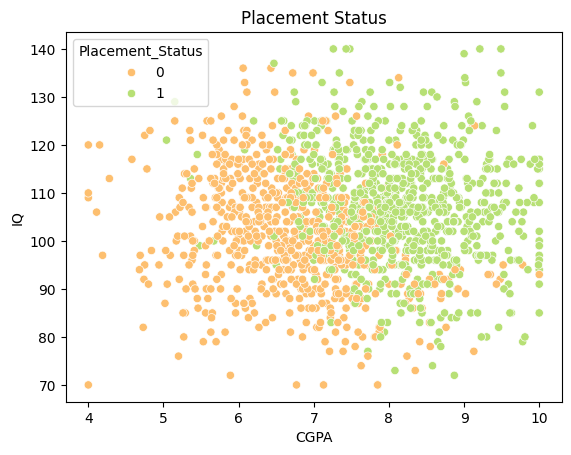

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# The correct Seaborn syntax
sns.scatterplot(data=df, x="CGPA", y="IQ", hue="Placement_Status", palette="RdYlGn")

# Add labels and show
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("Placement Status")
plt.show()

In [7]:
from sklearn.linear_model import Perceptron

In [8]:
model = Perceptron()
X = df.drop("Placement_Status",axis = 1)
y = df["Placement_Status"]

In [9]:
model.fit(X,y)

Perceptron()

In [10]:
model.predict([[6.25,83]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


array([1])

In [11]:
model.coef_

array([[1942.97, -115.  ]])

In [12]:
model.intercept_

array([-259.])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

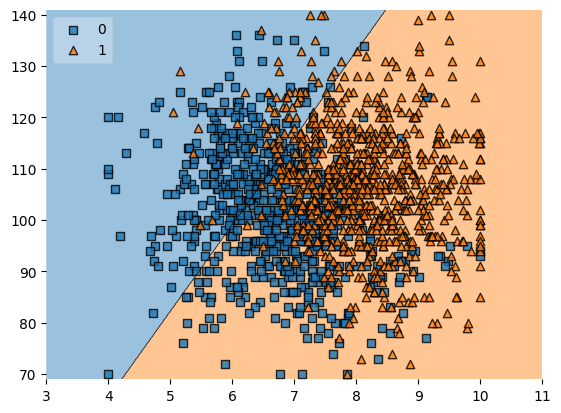

In [13]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values,y.values,clf = model,legend =2)